# <font color='blue'>Ising Model Worksheet</font>

<font color='darkcyan'>วิชา Statistical Mechanics รศ.ดร.ทีปานิส ชาชิโย \<teepanisc@nu.ac.th\> <br> ภาควิชาฟิสิกส์ คณะวิทยาศาสตร์ มหาวิทยาลัยนเรศวร</font>

ในบทเรียนนี้เราจะศึกษา การจัดเรียงของ spin หรือ "โมเมนต์แม่เหล็ก" (magnetic moment) ของอะตอม ว่าเกี่ยวข้องอย่างไรกับอุณหภูมิและกระบวนการสุ่มในวิชา Statistical Mechanics 

สมมุติให้มีอะตอมจำนวน $N$ (เช่น $N=100$) เรียงกันใน 1 มิติ &nbsp; แต่ละอะตอม สามารถมี magnetic moment ได้สองอันคือ $\mu \in \{ +\mu_0, -\mu_0 \}$ เราสนใจหาค่า 

1. โมเมนต์แม่เหล็กรวมของระบบ $M = \sum_i \mu_i$ หรือ
2. โมเมนต์แม่เหล็กเฉลี่ย $\bar{\mu} = \frac{1}{N}\sum_i \mu_i$

ว่าขึ้นอยู่กับอุณหภูมิหรือปัจจัยภายนอกเช่น สนามแม่เหล็ก $\vec{B} = B\hat{z}$ อย่างไรบ้าง

พิจารณาเฉพาะอะตอม $i^\text{th}$ &nbsp; *เราสร้างโค้ดไพทอน* เพื่อเลือก magnetic moment ว่าจะมีค่าเป็น $+\mu_0$ หรือ $-\mu_0$ ดังต่อไปนี้

```python
def random_moment(Ep,Em,kBT):

```

ฟังก์ชันนี้ สุ่ม magnetic moment ของอะตอมหนึ่ง **แต่สุ่มแบบมีเงื่อบไข** ตาม Boltzmann Distribution คือ อาศัยพลังงาน $\{E_+,E_-\}$ (ในโปรแกรมใช้ตัวแปร `{Ep,Em}`) ของแต่ละสถานะ

In [1]:
import numpy as np
import random

mu0 = 1.

def random_spin(Ep,Em,kBT):
    Z = np.exp(-Ep/kBT) + np.exp(-Em/kBT)
    Pp = np.exp(-Ep/kBT)/Z
    r = random.random()
    if(r < Pp): return +mu0 
    else: return -mu0
    

จากโค้ดข้างต้น เรารับค่าพลังงานของ 2 สถานะที่เป็นไปได้ $\{E_+,E_-\}$ จากนั้นทำการคำนวณ Partition Function

$$
Z = e^{-E_+/k_B T} + e^{-E_-/k_B T}
$$

เพื่อทำการคำนวณ ความน่าจะเป็น (Probability) ที่อนุภาคนี้จะมีสถานะหงายขึ้น ($\mu = +\mu_0$)

$$
P_+ = \frac{1}{Z}e^{-E_+/k_B T}
$$

จากนั้น เราทำการสุ่มเลือกตัวเลขระหว่าง $r \in [0,1]$ ขึ้นมาโดยการเรียกโมดูล random ของไพทอน  &nbsp; หากเลข $r$ ที่ได้ อยู่ระหว่าง $[0,P_+]$ จะถือว่า อะตอมตัวนี้ **ชี้ขึ้น** หรือ $\mu = +\mu_0$

ถ้ามิเช่นนั้น ก็จะถือว่า **ชี้ลง** หรือ $\mu = -\mu_0$

นี้เอง คือ กระบวนการสุ่มโดยทั่วไป ที่เรียกว่า การจำลองแบบ Ising Model ที่ใช้กันแพร่หลายในการศึกษาสถาวะทางสถิติของระบบขนาดใหญ่ ที่มีอุณหภูมิ เข้ามาเกี่ยวข้อง

In [2]:
def get_Natom(N,B,kBT):
    mu = np.zeros(N)
    for i in range(N):
        Ep = -(+mu0)*B
        Em = -(-mu0)*B
        mu[i] = random_spin(Ep,Em,kBT)
    return mu


โค้ดข้างต้นคือการสร้าง magnetic moment ของทุกอะตอมในระบบ โดยอาศัยสูตรทั่วไปของการคำนวณพลังงานก็คือ

$$
E_i = -\vec{\mu}\cdot \vec{B}
$$

เมื่อเรากำหนดให้ $\vec{\mu} \in \{+\mu_0\hat{z}, -\mu_0\hat{z} \}$ และ $\vec{B} = B\hat{z}$ จะทำให้พลังงานที่ได้ มีอยู่สองลักษณะ ดังนี้

$$
\begin{aligned}
\text{if } \mu = +\mu_0 \quad \rightarrow E = E_+ = -(+\mu_0)B \\
\text{if } \mu = -\mu_0 \quad \rightarrow E = E_- = -(-\mu_0)B
\end{aligned}
$$

และพลังงานทั้งสองลักษณะนี้เอง ที่ส่งผ่านไปยัง `random_spin` เพื่อสุ่มหา magnetic moment ของแต่ละอะตอม จนครบ $N$ ตัวในที่สุด

## <font color='blue'>Statistically Meaningful</font>

เราสามารถเรียนรู้จากโค้ดข้างต้น ว่าจำนวนอะตอม $N$ จะต้องมีค่าเท่าใด? **การสุ่ม** จึงจะให้ผลลัพธ์อย่างมีนัยยะสำคัญเชิงสถิติ

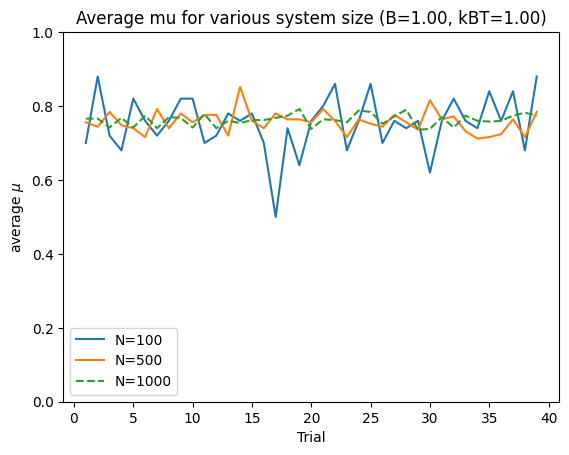

Standard Deviation (100,500,1000):0.0747,0.0289,0.0154


In [3]:
B = 1.
kBT = 1.
trial = np.arange(1,40,1)
N100 = []; N500 = []; N1000 = []
for i in trial:
    N100.append(  np.average(get_Natom( 100,B,kBT)) )
    N500.append(  np.average(get_Natom( 500,B,kBT)) )
    N1000.append( np.average(get_Natom(1000,B,kBT)) )

import matplotlib.pyplot as plt

plt.title('Average mu for various system size'
          ' (B=%.2f, kBT=%.2f)' % (B,kBT))
plt.plot(trial,N100,label='N=100')
plt.plot(trial,N500,label='N=500')
plt.plot(trial,N1000,'--',label='N=1000')
plt.ylim(0,1)
plt.xlabel('Trial')
#plt.xticks([1,10,20])
plt.ylabel('average $\mu$')
plt.legend()
plt.show()

print('Standard Deviation (100,500,1000):'
      '%.4f,%.4f,%.4f' % 
      (np.std(N100),np.std(N500),np.std(N1000)))


นักฟิสิกส์เชิงคำนวณ จะต้องรอบคอบและเข้าใจขีดจำกัดของ การจำลองของเราเสมอ $\quad$ กราฟข้างต้น แสดงการสุ่ม 40 ครั้ง ดังแสดงในแกนนอน $\quad$ แกนตั้ง คือ ค่าเฉลี่ย $\bar{\mu}$ ที่ได้จากการสุ่มแบบ Boltzmann Distribution

ค่า Standard Deviation ที่คำนวณออกมาก บอกเราว่า ยิ่งใช้จำนวนอะตอมในการคำนวณมากเท่าใด ค่าเฉลี่ยที่ได้ ก็จะแกว่งน้อยลงเท่านั้น กล่าวคือ ตีความเป็นค่าเฉลี่ยได้ดียิ่งขึ้น $\quad$ จากตัวเลขเราเห็นว่า ใช้ $N=100$ ก็ไม่ได้ขี้เหร่มากนัก เราเลือกใช้ตรงนี้ เพราะทำให้ความเร็วในการคำนวณสูงขึ้น

## <font color='blue'>Magnetic Field and Temperature</font>

เมื่อได้พารามิเตอร์และโค้ดการจำลองที่ดีแล้ว เราจะศึกษาค่าเฉลี่ย $\bar{\mu}$ ของระบบ ว่าขึ้นอยู่กับสนามแม่เหล็กภายนอก $\vec{B} = B\hat{z}$ และ อุณหภูมิ $T$ อย่างไรบ้าง &nbsp; การคำนวณ $\bar{\mu}$ ในครั้งนี้ เราจะใช้ $N=100$ ซึ่งจะให้ค่า $\bar{\mu}$ แกว่งอยู่ที่ระดับ $0.06-0.08$

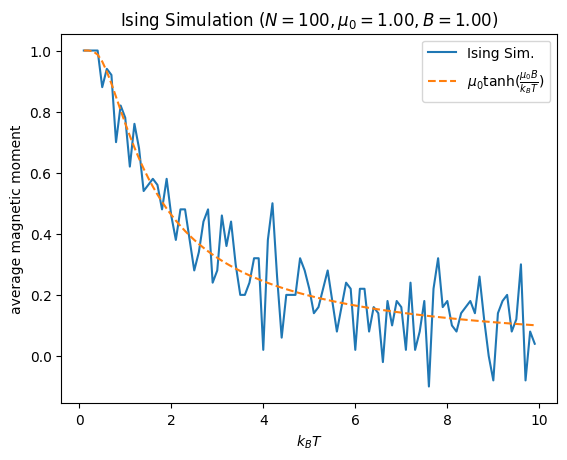

In [4]:
N = 100
B = 1.
kBT = np.arange(0.1,10,0.1)
mubar = np.zeros(len(kBT))
mubar_theory = mu0*np.tanh(mu0*B/kBT)
for i in range(len(kBT)):
    mubar[i] = np.average(get_Natom( N,B,kBT[i]))

plt.plot(kBT,mubar,label='Ising Sim.')
plt.plot(kBT,mubar_theory,'--',
         label='$\mu_0\\tanh(\\frac{\mu_0 B}{k_B T})$')
plt.legend()
plt.xlabel('$k_B T$')
plt.ylabel('average magnetic moment')
plt.title('Ising Simulation ($N=%d,\mu_0=%.2f,B=%.2f$)' 
          % (N,mu0,B))
plt.show()

โดยทั่วไปนั้น ผลของอุณหภูมิ $T$ คือ เกิดการแกว่งเชิงสถิติ ที่จะยิ่งมีแกว่งมากขึ้น เมื่ออุณหภูมิสูงขึ้น (random fluctuation) &nbsp; จากกราฟจะเห็นว่า เมื่ออุณหภูมิสูงมาก จะทำให้ค่า $\bar{\mu} \to 0$ &nbsp; นี้เป็นเพราะสนามแม่เหล็ก ไม่สามารถตรึงให้ magnetic moment ของแต่ละอะตอม ชี้ไปในทิศทางของสนามภายนอกได้อีกต่อไป เนื่องจากอุณหภูมิที่สูงทำให้ fluctuation มีค่าสูงมาก เกิดการแกว่ง $\mu \in \{+\mu_0, -\mu_0\}$ โดย <u>เท่าเทียมกัน</u> ทำให้ค่าเฉลี่ยเข้าสู่ศูนย์ นั่นเอง 

<div style="background-color: snow; padding: 10px; border-radius: 5px;">
<font color='green'>แบบฝึกหัด</font> ลองแก้จำนวนอะตอมในโค้ดข้างต้น ให้เป็น 1,000 หรือ 10,000 จะพบว่า ได้ค่าเฉลี่ยที่นิ่งมากขึ้น แต่ก็คำนวณช้าลงมาก 

<font color='green'>แบบฝึกหัด</font> ลองแก้ค่า $B = -1$ จะเห็นค่าเฉลี่ย $\bar{\mu}$ กลับทิศลงมาด้านล่าง
</div>

จากแบบฝึกหัดทั้งสองข้อ และการวิเคราะห์กราฟจะเห็นว่า หน้าที่ของสนามแม่เหล็ก $\vec{B}$ ก็คือการตรึงให้ magnemtic moment ของแต่ละอะตอม เรียงไปในทิศทางเดียวกันกับสนามแม่เหล็ก 


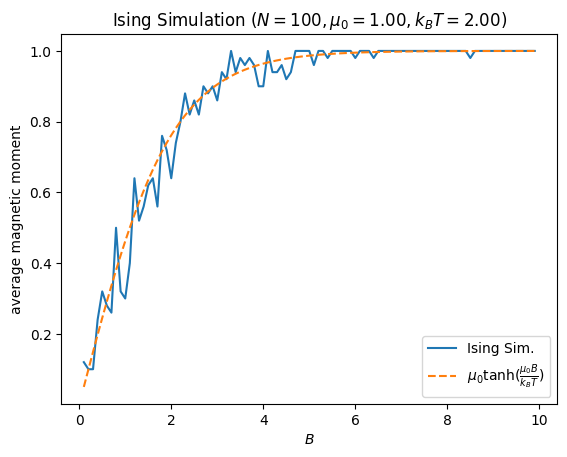

In [5]:
N = 100
kBT = 2.
B = np.arange(0.1,10,0.1)
mubar = np.zeros(len(B))
mubar_theory = mu0*np.tanh(mu0*B/kBT)
for i in range(len(B)):
    mubar[i] = np.average(get_Natom( N,B[i],kBT))

plt.plot(B,mubar,label='Ising Sim.')
plt.plot(B,mubar_theory,'--',
         label='$\mu_0\\tanh(\\frac{\mu_0 B}{k_B T})$')
plt.legend()
plt.xlabel('$B$')
plt.ylabel('average magnetic moment')
plt.title('Ising Simulation ($N=%d,\mu_0=%.2f,k_BT=%.2f$)' 
          % (N,mu0,kBT))
plt.show()

ข้างต้นแสดงให้เห็นผลของสนามแม่เหล็ก $B$ ได้ชัดเจนยิ่งขึ้น &nbsp; พิจารณาอุณหภูมิ คงที่ ค่าหนึ่ง เช่น $k_B T = 2.0$ เราจะเห็นว่า เมื่อสนามแม่เหล็กมีความเข้มสูง ทางด้านขวามือของกราฟ ค่า $\bar{\mu} \to +1$ ที่เป็นเช่นนี้ เพราะสนามมีความเข้มสูงมาก มันเอาชนะ fluctuation ของอุณหภูมิ $k_B T = 2.0$ ได้ง่ายดาย และมีอิทธิพลให้อะตอมทุกตัว ปรับทิศของ magnetic moment ไปในทางเดียวกันทั้งหมด

เมื่อสนามมีความเข้มน้อยลงมาก คือ $B \to 0$ ทางด้านซ้ายมือของกราฟ ความสามารถในการตรึง magnetic moment ก็น้อยลงเรื่อย ๆ จนกระทั่งแพ้ต่อ fluctuation ของอุณหภูมิทำให้ magnetic moment แกว่งแบบ 50-50 คือเป็น $\mu \in \{+\mu_, -\mu_0 \}$ โดยเท่าเทียมกัน ส่งผลให้ค่าเฉลี่ย เป็น ศูนย์ ในที่สุด

ระบบที่เมื่อสนามภายนอก หายไป สภาพการเป็นแม่เหล็กของสสารก็หายไปด้วย เรียกว่า **Paramagnetic System** กล่าวคือ การที่ระบบอันนี้ จะมี magnetic moment $\bar{\mu} \ne 0$ มันจะต้องพึ่งพาสนามจากภายนอกเข้ามาเหนี่ยวนำ นั่นเอง

## <font color='blue'>Ferromagnetic System</font>

เรียกให้เข้าใจง่ายว่า แม่เหล็กถาวร  &nbsp; แท่งแม่เหล็กของเล่นที่เราคุ้นเคยนั้น เป็นแม่เหล็กถาวร กล่าวคือ มันสามารถรักษาสภาพแม่เหล็ก $\bar{\mu} \ne 0$ ได้แม้ไม่ต้องมีสนามภายนอกมาคอยเหนี่ยวนำ &nbsp; ในทางทฤษฎีเราสามารถใช้การประมาณแบบ Weiss's approximation เพื่อศึกษาเงื่อนไขนี้ได้ แต่ในการนี้ เราจะใช้ขั้นตอนการจำลอง แล้วเปรียบเทียบผลทางทฤษฎี

พิจารณาพลังงาน $E_i$ ของ magnetic moment อันหนึ่งที่อยู่ภายในระบบ เราเรียกอะตอมนี้ ด้วยดัชนี $i$

$$
E_i = -\vec{\mu}_i\cdot\vec{B}_\text{ext} \quad \underbrace{ - J\vec{\mu}_{i-1}\cdot\vec{\mu}_{i} - J\vec{\mu}_i\cdot\vec{\mu}_{i+1} + \cdots }_{\text{Interaction with Neighbors}}
$$

จากสมการข้างต้น เทอมแรกของพลังงานเป็นอันตรกิริยากับสนามแม่เหล็กภายนอก $\vec{B}_\text{ext}$ ซึ่งเราเติมตัวอักษร $\text{ext}$ ย่อมาจาก external เพื่อความชัดเจน เทอมแรกนี้ปรากฎอยู่เช่นกรณี Paramagnetic ดังที่ผ่านมา

เทอมที่สอง คือส่วนเพิ่มเติม เป็นอันตรกิริยาระหว่างตัวมันเอง (แทนด้วย $\vec{\mu}_i$) และเพื่อนที่อยู่ข้าง ๆ &nbsp; ในกรณี 1 มิติ มีอยู่เพียง 2 ตัวซ้ายขวา แต่ในกรณีหลายมิติขึ้น อาจจะมีมากขึ้น 

เทอมของพลังงานนี้ อยู่ในรูป

$$
- J \vec{\mu}_i \cdot \vec{\mu}_j
$$

โดยมีค่าคงที่ $J$ เรียกว่า exchange interaction constant &nbsp; ถ้า $J > 0$ จะทำให้อะตอมที่อยู่ข้างกัน เรียงไปทิศเดียวกัน แต่ถ้า $J < 0$ มันจะชอบสลับทิศทางกัน

เพราะฉะนั้น พลังงานของอะตอม $i$ เขียนให้อยู่ในรูปของซัมเมชันได้ว่า

$$
E_i = -\mu_i B_\text{ext} - J \mu_i \sum_{j \in \text{Neighbors}}\mu_j
$$

โดยที่ดัชนี $j$ คือซัมเมชันเฉพาะอะตอมที่อยู่ใกล้เคียง

### Weiss Approximation

ซัมเมชันที่เกิดขึ้น ส่งผลให้เกิดความซับซ้อนทางคณิตศาสตร์ ทำให้เราไม่สามารถหาสภาพสนามแม่เหล็กของทั้งระบบ $\bar{\mu}$ ออกมาได้ 

Weiss mean-field approximation คือ การ<u>แทน</u> $\mu_j$ ที่อยู่รอบ ๆ <u>ด้วยค่าเฉลี่ย</u>ของระบบไปเลย กล่าวคือ

$$
\text{Weiss Approximation: } \qquad \mu_j = \bar{\mu}
$$

ดังนั้น พลังงานของอะตอม $i$ จึงเขียนได้เป็น

$$
E_i = -{\mu}_i {B}_\text{ext} - J \mu_i(n\bar{\mu}) \tag{1}
$$

จะเห็นว่า เราแทนพลังงานอันตรกิริยากับตัวข้างเคียง ที่เดิมเขียนในรูปของซัมเมชัน ให้เป็น $n(\bar{\mu})$ เมื่อ $n$ คือ จำนวนอะตอมข้างเคียง &nbsp; ในกรณี 1 มิติมีซ้ายและขวา เราสามารถกำหนดให้ $n = 2$

เมื่อพลังงาน นิยามเช่นนี้ เราจะต้องคำนวณพลังงานกันใหม่ในโค้ดของ `def getNatom` ดังนี้

In [6]:
def get_Natom_ferro(N,mu,J,n,Bext,kBT):

    for i in range(N):

        mubar = np.average(mu)

        Bint = J*mubar
        Ep = -(+mu0)*(Bext + J*n*mubar)
        Em = -(-mu0)*(Bext + J*n*mubar) 

        mu[i] = random_spin(Ep,Em,kBT)
    return mu

จากตัวอย่างข้างต้น โครงสร้างของโค้ดยังคงเหมือนเดิม จะต่างก็เพียงวิธีการคำนวณพลังงานเท่านั้น การสุ่มเลือก การหา Partition Function ใน `random_spin(Ep,Em,kBT)` ยังคงเหมือนเดิมทุกประการ

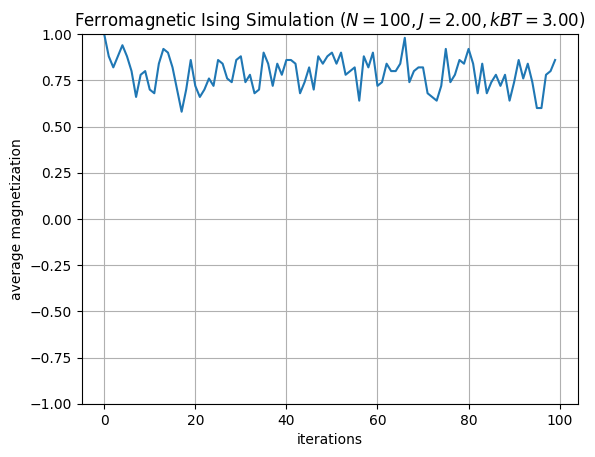

average: 0.78, dev: 0.09


In [7]:
N = 100
Bext = 0.
J = 2.
n = 2
kBT = 3.0

# initial mu
mu = [1.]*N
mubar = []
for i in range(100):
    mubar.append( np.mean(mu) )
    mu = get_Natom_ferro(N,mu,J,n,Bext,kBT)

plt.plot(mubar)
plt.xlabel('iterations')
plt.ylabel('average magnetization')
plt.title('Ferromagnetic Ising Simulation ($N=%d, J=%.2f, kBT=%.2f$)' 
          % (N,J,kBT))
plt.ylim(-1,1)
plt.grid()
plt.show()

# statistics
print('average: %.2f, dev: %.2f' 
      % (np.average(mubar[-50:]), np.std(mubar[-50:])))


กราฟข้างต้น คือการหาค่า $\bar{\mu}$ ของระบบ Ferromagnetic **แม้ไม่มีสนามภายนอก** &nbsp;

เดิมในกรณี Paramagnetic ที่ผ่านมานั้น เมื่อ magnetic moment ถูกตรึงจากสนามภายนอกเพียงอย่างเดียว เราจึงทราบว่า $\bar{\mu} = 0$ เมื่อ $B_\text{ext} = 0$

แต่ในกรณี Ferromagnetic  เปรียบเทียบให้เข้าใจง่ายว่า เพื่อนที่อยู่ข้าง ๆ ก็สามารถบอกเราได้ว่า ให้ชี้ในทิศ ขึ้น-หรือ-ลง ดังนั้น แม้ปราศจากสนามภายนอกมาคอยกำกับ ก็ยังมี **สนามจากภายใน** คอยตรึงกันไว้ ส่งผลให้ $\bar{\mu} \ne 0$

การที่เราต้องทำการจำลองหลายรอบ จนกว่าระบบจะเข้าสู่สมดุล ก็เพราะพลังงานของแต่ละอะตอม ขึ้นอยู่กับค่าเฉลี่ย $\bar{\mu}$ &nbsp; ดังนั้นหากเราไม่ทราบเซตของ $\{ \mu_i \}$ ของทุกอะตอมแต่แรก ก็ย่อมคำนวณพลังงานไม่ได้

วิธีการแก้คือ การเดา $\{ \mu_i \}$ ขึ้นมาก่อน แล้วค่อยคำนวณวนซ้ำหลายรอบ จนกว่าคำตอบจะเข้าสู่สมดุล &nbsp; จากราฟ แกนนอนคือจำนวนรอบ แกนตั้งคือ $\bar{\mu}$ ของรอบนั้น ๆ &nbsp; จากข้อสังเกตตรงนี้ เราพบว่าเมื่อผ่านรอบที่ 50 ไปแล้ว $\bar{\mu}$ จะเริ่มนิ่ง ดังนั้นเราเอาข้อมูล 50 รอบสุดท้ายมาหาค่าเฉลี่ย พร้อมหา standard deviation เพื่อให้เห็นการแกว่งเชิงสถิติ ดังแสดงในตัวเลขด้านล่างของกราฟ

จากพารามิเตอร์ เบื้องต้น ถ้ากำหนดให้ J = 2, n = 2, kBT = 3 จะพบว่า มี average $\bar{\mu} = 0.79 \pm 0.09$ เป็นต้น &nbsp; นี้แสดงว่า แม้สนามแม่เหล็กภายนอก $B_\text{ext} = 0$ แต่ระบบก็ยังสามารถรักษาความเป็นแม่เหล็กเอาไว้ได้ หรืออีกนัยหนึ่ง เป็นแม่เหล็กถาวร นั่นเอง  

<div style="background-color: snow; padding: 10px; border-radius: 5px;">
<font color='green'>แบบฝึกหัด</font> จงปรับให้อุณหภูมิสูงขึ้น เป็น kBT=3.3 พบว่าได้ average $\bar{\mu}$ เป็นเท่าใด?
</div>

## <font color='blue'>Phase Transition</font>

คราวนี้มาถึงการจำลองทางฟิสิกส์ ที่น่าสนใจ และเป็นไฮไลท์ของใบงานชิ้นนี้ คือ การเปลี่ยนเฟสของสสาร หรือ Phase Transition เมื่ออุณหภูมิถึงจุดวิกฤต ค่าหนึ่ง

เมื่อกล่าวถึง Phase Transition เรานึกถึงการเปลี่ยนสถานะของสสาร จากของแข็ง เป็นของเหลว หรือ ก๊าซ ลักษณะการเปลี่ยนเฟสเช่นนี้ เกิดขึ้นเมื่ออุณหภูมิถึงจุดวิกฤตค่าหนึ่ง เขียนด้วยสัญลักษณ์​ $T_c$ และในการศึกษาฟิสิกส์ที่ผ่านมาตั้งแต่มัธยม หรืออุดมศึกษา เรายังไม่เคยมีโอกาสทำนายทางทฤษฎีเลยว่า $T_c$ ของระบบหนึ่ง ๆ มีค่าเป็นเท่าใด


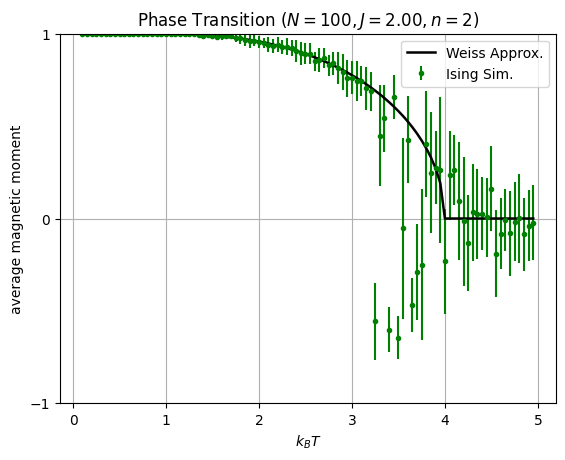

In [8]:
from scipy.optimize import fsolve

N = 100
J = 2.
n = 2

def get_mubar_theory(kBT):
    a = (mu0**2*J*n)/kBT
    func = lambda x: x - np.tanh(a*x)
    return mu0 * fsolve(func, 1., maxfev=1000)[0]

def get_mubar(kBT):
    mu = [+mu0]*N
    mubar = []
    for i in range(100):
        mubar.append( np.mean(mu) )
        mu = get_Natom_ferro(N,mu,J,n,Bext,kBT)

    return np.average(mubar[-50:]), np.std(mubar[-50:])

kBT = np.arange(0.1,5,0.05)
mubar = []; muerr = []; mubar_theory = []
for i in range(len(kBT)):
    mean, dev = get_mubar(kBT[i])
    mubar.append( mean )
    muerr.append( dev )
    mubar_theory.append( get_mubar_theory(kBT[i]) )

plt.errorbar(kBT,mubar,yerr=muerr,fmt='g.',
             label='Ising Sim.')
plt.plot(kBT,mubar_theory,'k-',linewidth=1.8,
         label='Weiss Approx.')
plt.ylim(-1,1)
plt.yticks([-1,0,1])
plt.xlabel('$k_B T$')
plt.ylabel('average magnetic moment')
plt.title('Phase Transition ($N=%d, J=%.2f, n=%d$)' 
          % (N,J,n))
plt.legend()
plt.grid()
plt.show()

กราฟที่เห็น คือ การจำลองด้วยวิธี Ising Model (สีเขียว) ที่คำนวณ average $\bar{\mu}$ ของระบบ Ferrormagnet ที่อุณหภูมิต่าง ๆ กัน &nbsp; เส้นทึบสีดำคือค่าที่ได้จากทฤษฎี ที่เราจะได้กล่าวถึงในภายหลัง

นี้เป็นการจำลองในสภาวะ $B_\text{ext} = 0$ ดังนั้นสภาพความเป็นแม่เหล็ก $\bar{\mu} \ne 0$ ที่เห็นในกราฟ เกิดจากการยึดตรึงกันเอง ระหว่างอะตอมภายในระบบ

ในเบื้องต้น เริ่มจากอุณหภูมิต่ำ $T \approx 0$ จะพบว่า $\bar{\mu} = 1$ ระบบมีสถานะเป็น Ferromagnet คือรักษาแม่เหล็กถาวรของตนเองไว้ได้

ก็ต่อเมื่ออุณหภูมิสูงถึงขั้นหนึ่ง เราจะสังเกตการเปลี่ยนแปลงไม่ต่อเนื่องชัดเจน คือ  $\bar{\mu} = 0$ และถ้าอุณหภูมิสูงมากกว่านี้ ระบบจะยังคงเป็น $\bar{\mu} = 0$ อยู่เช่นเดิม &nbsp; เราเรียกอุณหภูมิเป็นจุดเปลี่ยนผ่านตรงนี้ว่า Critical Temperature $T_c$

### Theoretical Curve

จากกราฟจะเห็นเส้นสีดำทึบ ที่ได้จากทฤษฎี Weiss Approximation ซึ่งให้ผลตรงกับการจำลองเป็นที่น่าพอใจ โดยมีวิธีการวิเคราะห์ ดังต่อไปนี้

พิจารณา $B_\text{ext} = 0$ จะทำให้พลังงานในสมการ (1) กลายเป็น

$$
E_i = - J \mu_i (n \bar{\mu}) = -\mu_i \underbrace{ (J n \bar{\mu}) }_{B_\text{int}} = -\mu_i B_\text{int}
$$

ข้างต้นเราจัดเทอมสักเล็กน้อย โดยรวมเอา $(J n \bar{\mu})$ มาไว้กลุ่มเดียวกัน แล้วตีความว่า มันทำหน้าที่เหมือนสนามแม่เหล็ก **ภายใน** $B_\text{int}$

การเขียนเทอมในลักษณะนี้ ทำให้โครงสร้างทางคณิตศาตร์ เหมือนเดิมทุกประการ กับการหาค่าเฉลี่ย $\bar{\mu}$ ที่เราเคยทำมา เพียงแต่เปลี่ยนชื่อ จาก $B_\text{ext} \rightarrow B_\text{int}$

เมื่อเป็นดังนี้ เรายังคงเขียนค่าเฉลี่ยให้อยู่ในรุป 

$$
\bar{\mu} = \mu_0 \tanh( \frac{\mu_0 B_\text{int}}{k_B T}) 
$$

แทน $B_\text{int} = J n \bar{\mu}$ จะได้

$$
\bar{\mu} = \mu_0 \tanh(\frac{\mu_0 J n \bar{\mu}}{k_B T}) \tag{2}
$$

นี้เป็นสมการที่เราต้องแก้ เพื่อหา $\bar{\mu}$ ของระบบ โดยก่อนที่จะใช้ไพทอนแก้หาคำตอบ เราจัดรูปเล็กน้อย คือ

$$
x - \tanh(a x) = 0, \quad x \equiv \frac{\bar{\mu}}{\mu_0},\quad  a = \frac{\mu_0^2 J n}{k_B T} \tag{3}
$$

เมื่อทราบคำตอบ $x$  จึงคำนวณย้อนกลับมาเป็น $\bar{\mu}$ ที่ได้จากทฤษฎี

><font color='darkcyan'>**หมายเหตุ**: คำขอให้ AI สร้างโค้ดไพทอนเพื่อแก้สมการ $x - \tanh(a x) = 0$ คือ: I have a root finding problem a*x - tanh(x) = 0, where a is a constant, show me python code that find the root x</font>

เมื่อปรับแก้คำตอบจาก AI เล็กน้อย จึงได้เป็นฟังก์ชัน

```python
def get_mubar_theory(kBT):
```

จากกราฟเส้นดำทึบจะพบว่า ให้ผลตรงกันกับการจำลองด้วยการสุ่ม &nbsp; นอกจากนี้ หากสังเกตผลจากการสุ่มพบว่า มีการแกว่งอยู่มากพอสมควร โดยค่า error bar ที่แสดงนั้นมาจากการคำนวณ standard deviation ของการหาค่าเฉลี่ย $\bar{\mu}$ ที่อธิบายไว้ก่อนหน้านี้ นั่นเอง


<font color='green'>แบบฝึกหัด</font> แก้โค้ดข้างต้นให้การเดาค่า $\{\mu_i\}$ ไม่ต้องกำหนดให้เป็น $+\mu_0$ ทั้งหมด แต่ใช้การสุ่มระหว่าง $+\mu_0,-\mu_0$ ด้วยการเปลี่ยนบรรทัด 13 ให้เป็น 

```python
mu = [random.choice([-mu0, +mu0]) for _ in range(N)]
```

จากแบบฝึกหัดข้างต้นจะพบว่า หากเราเปลี่ยนวิธีการตั้งค่าเริ่มต้น ของ $\{ \mu_i \}$ ในบางครั้ง magnetic moment ของทั้งระบบ จะไปเกิดสมดุลที่ $\bar{\mu} < 0$ หรือ **ติดลบ** &nbsp; นี้เป็นพฤติกรรมปรกติเพราะในทางทางฟิสิกส์ เราไม่สามารถไปกำหนดได้ว่า ทิศใดกันแน่ เป็นทิศที่เหมาะสม เพราะทั้งสองทิศทาง มีความสมมาตร และเหมือนกันทุกประการ ตราบเท่าที่ไม่มีสนามแม่เหล็กภายนอกมาเป็นตัวจำแนก

## <font color='blue'>Critical Temperature $T_c$</font>

ในห้องเรียน เราใช้ตรรกะในการหาค่า $T_c$ ของการหลอมเหลว จากสถานะ Ferromagnet มาเป็น Paramagnet โดยเริ่มจากสมการ (2) เราปรับรูปให้วิเคราะห์ด้วยกราฟได้ง่ายขึ้นเป็น

$$
\begin{aligned}
\bar{\mu} & = \mu_0 \tanh( \frac{\mu_0 J n \bar{\mu}}{k_B T} ) \\
a x & = \tanh(x), \quad x \equiv \frac{\mu_0 J n \bar{\mu}}{k_B T}, a = \frac{k_B T}{\mu_0^2 J n} 
\end{aligned}
$$

สมการ $a x = \tanh(x)$ มีผลเฉลย แปลว่าเราสามารถหา $\bar{\mu}$ ที่ทำให้สมการเป็นจริง หรืออีกนัยหนึ่ง ระบบมีสภาพเป็นแม่เหล็กนั่นเอง

สมการ $a x = \tanh(x)$ จะเป็นจริงได้ เมื่อมีการตัดกันของกราฟ $ax$ และ $\tanh(x)$ ในห้องเรียนเราวาดกราฟแล้วเห็นว่า มันจะตัดกันได้ก็ต่อเมื่อ 

$$
a < 1 \quad \rightarrow \quad \frac{k_B T}{\mu_0^2 J n} < 1
$$

หรือจัดรูปได้ว่า

$$
\boxed{ k_B T_c = \mu_0^2 J n}
$$

นี้เองคือสมการการทำนายอุณหภูมิวิกฤต ที่เปลี่ยนสถานะของแม่เหล็ก จาก Ferromagnet เป็น Paramagnet และเป็นสิ่งที่น่าทึ่งในทางทฤษฎีของวิชา Statistical Mechanics ที่เพียงการนับความน่าจะเป็น การหาค่าเฉลี่ย สามารถทำนายพฤติกรรมของสสาร ได้อย่างแม่นยำ ถึงเพียงนี้

<div style="background-color: snow; padding: 10px; border-radius: 5px;">
<font color='green'>แบบฝึกหัด</font> ย้อนไปโค้ดไพทอน และปรับพารามิเตอร์ J,n และตรวจสอบกราฟจากทฤษฎีและการจำลองว่า ให้ผลตรงกัน และสมการข้างต้น ทำนาย $T_c$ ได้อย่างถูกต้อง
</div>